In [ ]:
#Importando as bibliotecas relevantes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
sns.set_palette('pastel')

#Carregando os dados

In [ ]:
df = pd.read_csv("/content/sample_data/loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


#Pré-processamento

In [ ]:
#Checando se existem valores nulos nos dados
print("Coluna  | Número de entradas nulas")
df.isna().sum()

Coluna  | Número de entradas nulas


,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [ ]:
#Checando se há linhas duplicadas nos dados
print('Número de linhas duplicadas: ', df.duplicated().sum())

Número de linhas duplicadas:  0


In [ ]:
#Observando o formato dos dados em cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [ ]:
#Salvando variável 'purpose' e as variáveis binárias em dados categóricos
for col in ['purpose', 'credit.policy', 'not.fully.paid']:
    df[col] = df[col].astype('category')

In [ ]:
#Analisando quais as categorias possíveis para a variável 'purpose'
print('Variável: Purpose ')
print('Número de entradas únicas: ',df['purpose'].nunique())
print('Categorias de propósito: ', df['purpose'].unique())

Variável: Purpose 
Número de entradas únicas:  7
Categorias de propósito:  ['debt_consolidation', 'credit_card', 'all_other', 'home_improvement', 'small_business', 'major_purchase', 'educational']
Categories (7, object): ['all_other', 'credit_card', 'debt_consolidation', 'educational',
                         'home_improvement', 'major_purchase', 'small_business']


#Análise Exploratória dos Dados

Análise Univariacional

In [ ]:
#Analisando medidas como média, desvio padrão e quartis de todas as colunas numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01
delinq.2yrs,9578.0,0.163708,0.546215,0.000000,0.000000,0.000000,0.000000,1.300000e+01


In [ ]:
#Alguns registros de revol.util possuem porcentagem acima de 100%. Arrumamos estes dados para que a porcentagem máxima seja 100%

df_revolutil_100 = df.index[df['revol.util']>100]
df.loc[df_revolutil_100, 'revol.util'] = 100

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.787887,28.992156,0.000000,22.600000,46.300000,70.900000,1.000000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01
delinq.2yrs,9578.0,0.163708,0.546215,0.000000,0.000000,0.000000,0.000000,1.300000e+01


In [ ]:
#Definindo funções para plotar gráficos de análise univariacional

def category_plot(data):
    '''
    Cria gráfico de contagem para todas as variáveis categóricas no dataframe.
    Args:
        data (DataFrame): dataframe contendo SOMENTE COLUNAS CATEGÓRICAS
    Output:
        None: retorna os gráficos de contagem utilizando o seaborn.
    '''

    num_of_rows = int(np.ceil(data.shape[1]/3))
    fig, axes = plt.subplots(num_of_rows, 3, figsize=(20, 7))
    fig.suptitle(f'Análise de Frequência', fontsize=20)
    for i, col in enumerate(data.columns):
        row = int(np.floor(i/3))
        column = int(i % 3)
        sns.countplot(x = data[col], ax=axes[column], hue=data[col], palette='Set2', legend=True)
        axes[column].set_title(f'Frequência de {col}', fontsize=17)
    plt.tight_layout()
    plt.show()


def numerical_plot(data):
    '''
    Cria um histograma e um gráfico de caixa para todas as colunas numéricas do dataframe.
    Args:
        data (DataFrame): dataframe contendo SOMENTE COLUNAS NUMÉRICAS.
    Output:
        None: retorna gráficos utilizando o seaborn.
    '''


    for col in data.columns:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        fig.suptitle(f'Análise de {col}', fontsize = 20)
        #Histograma
        sns.histplot(data[col], ax=axes[0], bins = 10)
        axes[0].set_title(f'Histograma de {col}', fontsize=14)
        axes[0].set_xlabel(col, fontsize=12)
        axes[0].set_ylabel('Frequência', fontsize=12)
        #Gráfico de caixa
        sns.boxplot(x=data[col], ax=axes[1])
        axes[1].set_title(f'Gráfico de caixa de {col}', fontsize=14)
        axes[1].set_ylabel(col, fontsize=12)
        skew = stats.skew(data[col])
        print(f'Skewness dos dados de {col} é: ', skew)
        plt.show()

In [ ]:
#Separando as colunas do dataframe em categóricas e numéricas
cat_cols = []
num_cols = []
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        num_cols.append(col)
    else:
        cat_cols.append(col)

Skewness dos dados de int.rate é:  0.16439416280317964


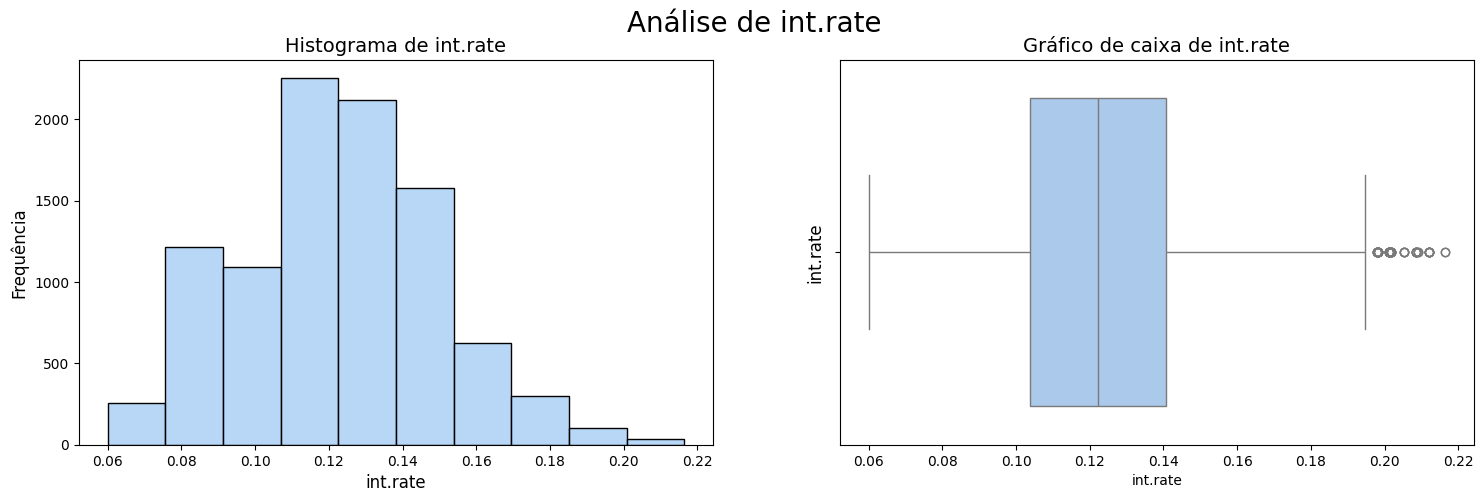

Skewness dos dados de installment é:  0.9123795470488175


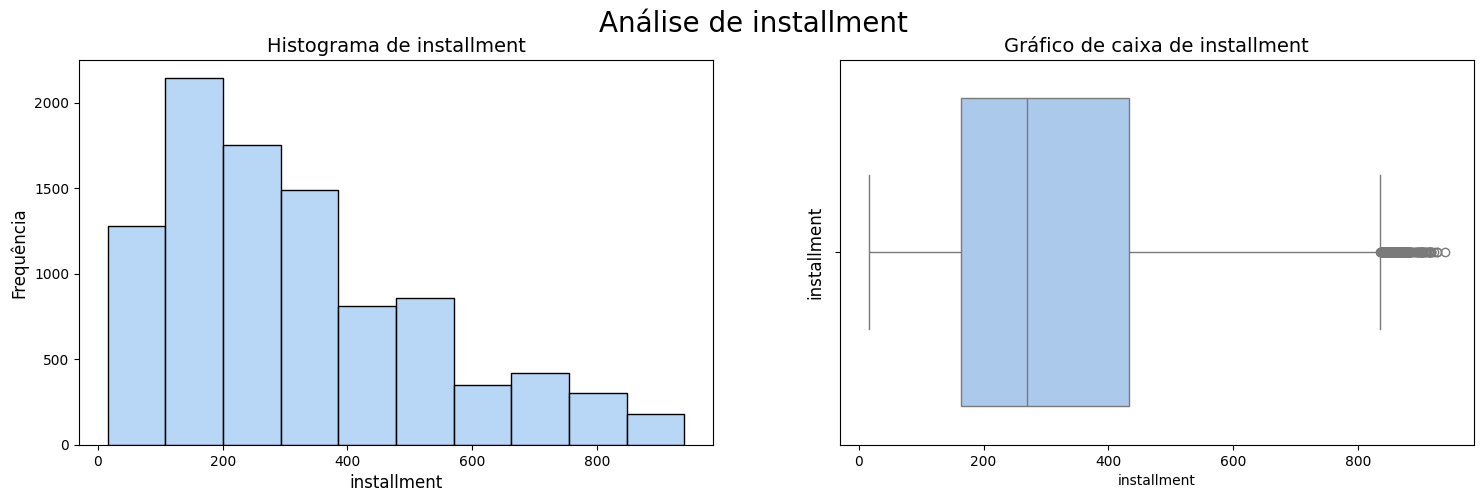

Skewness dos dados de log.annual.inc é:  0.028663616694390843


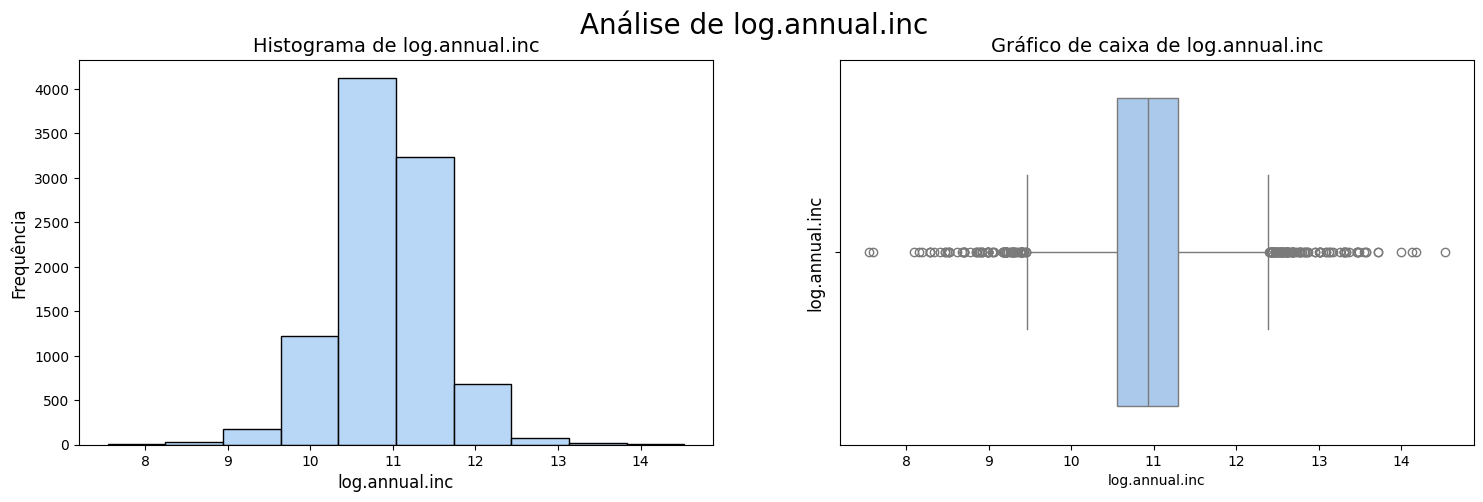

Skewness dos dados de dti é:  0.02393727340906256


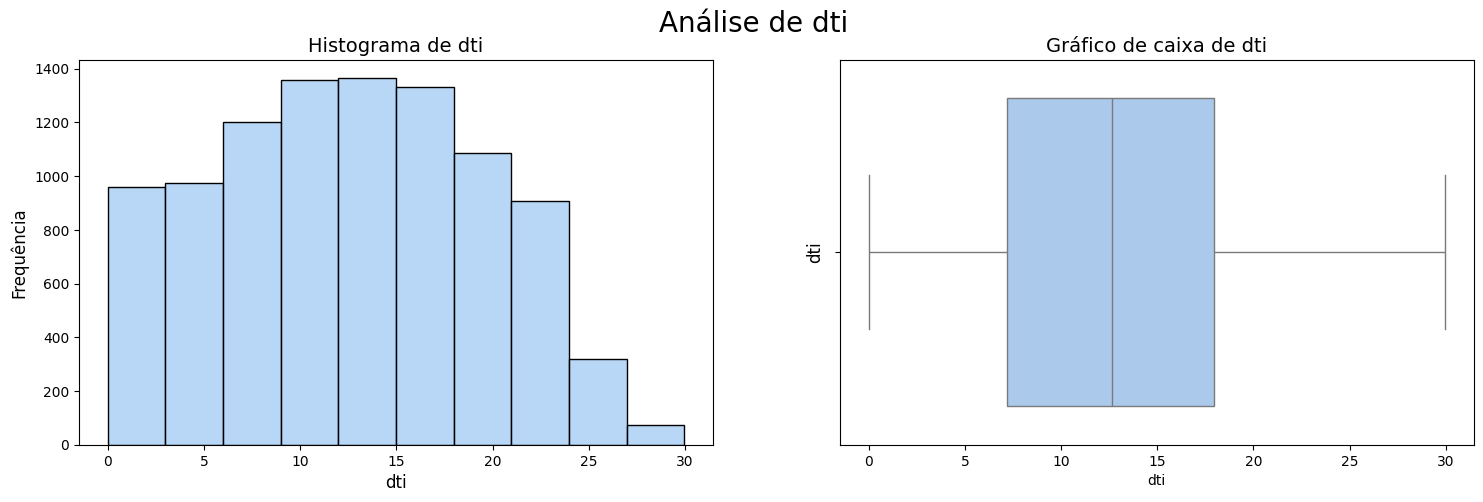

Skewness dos dados de fico é:  0.47118593325420144


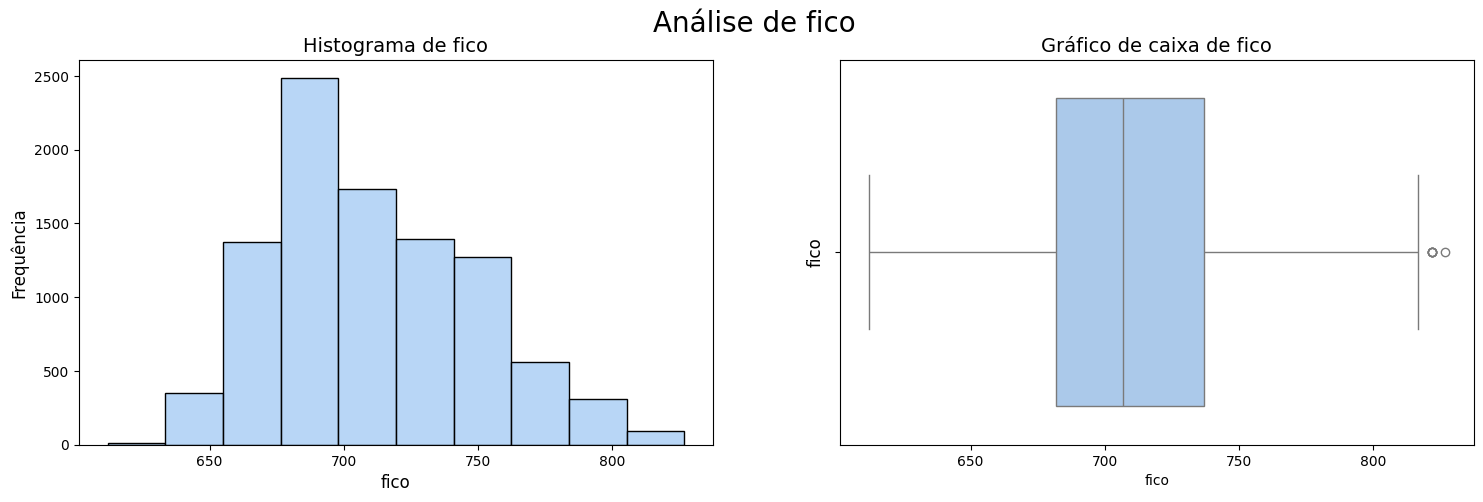

Skewness dos dados de days.with.cr.line é:  1.1555672187692227


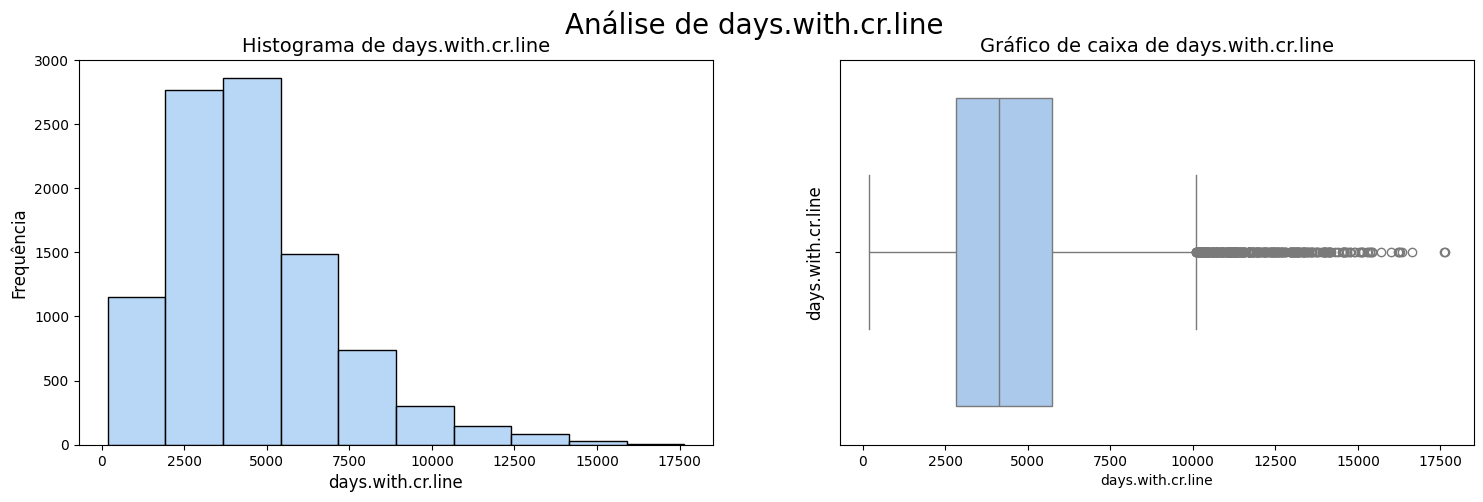

Skewness dos dados de revol.bal é:  11.15931049753884


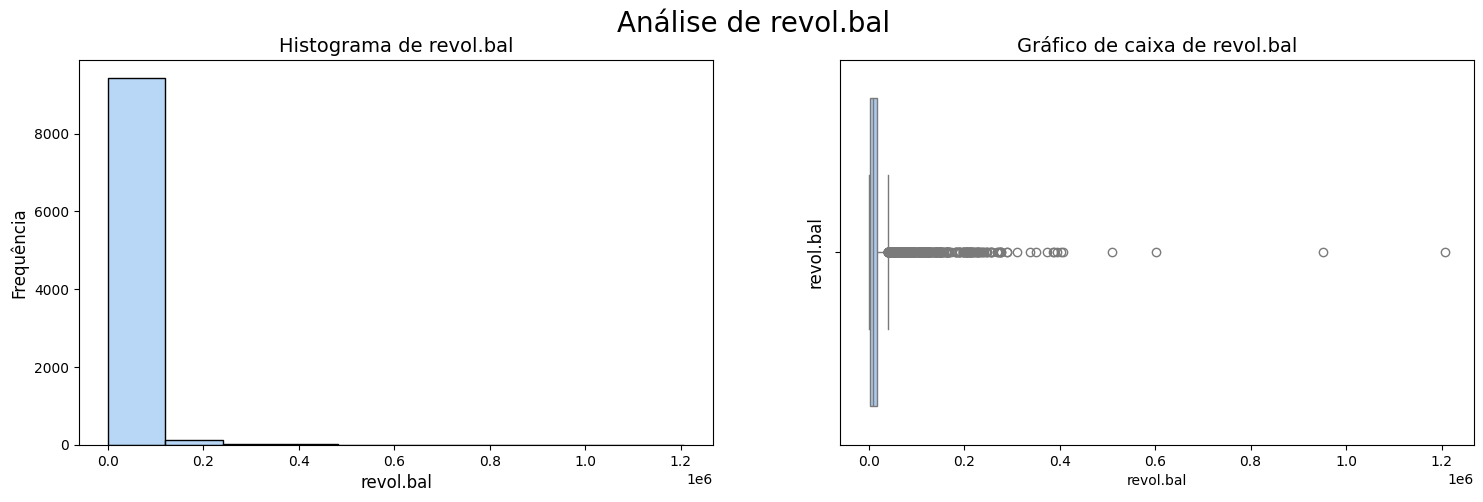

Skewness dos dados de revol.util é:  0.056746599455224214


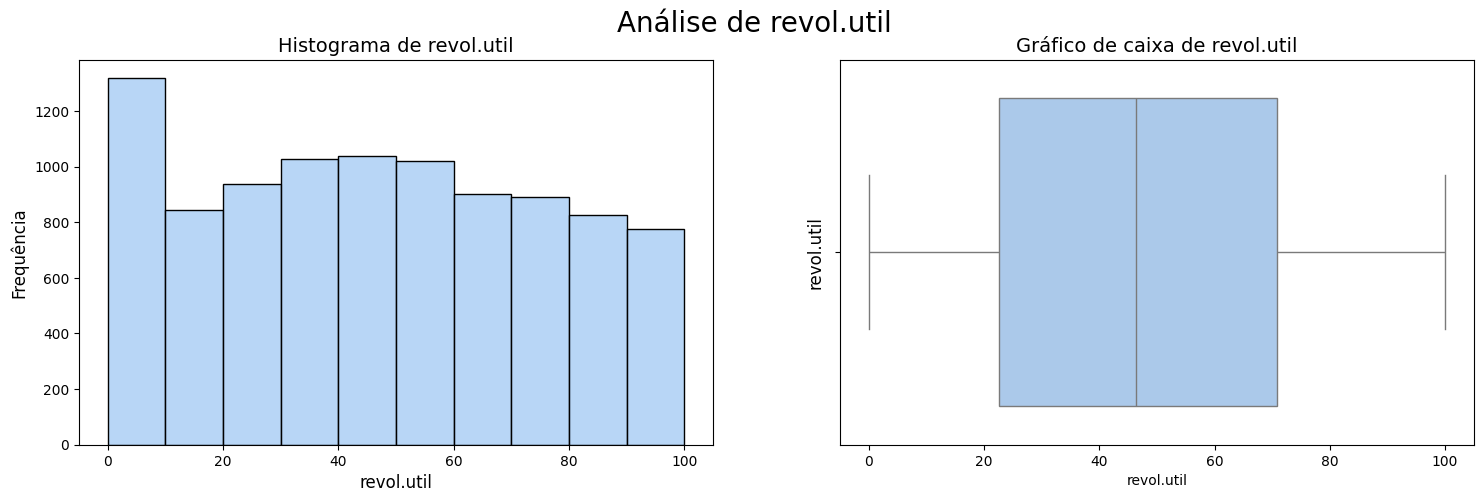

Skewness dos dados de inq.last.6mths é:  3.583589522053665


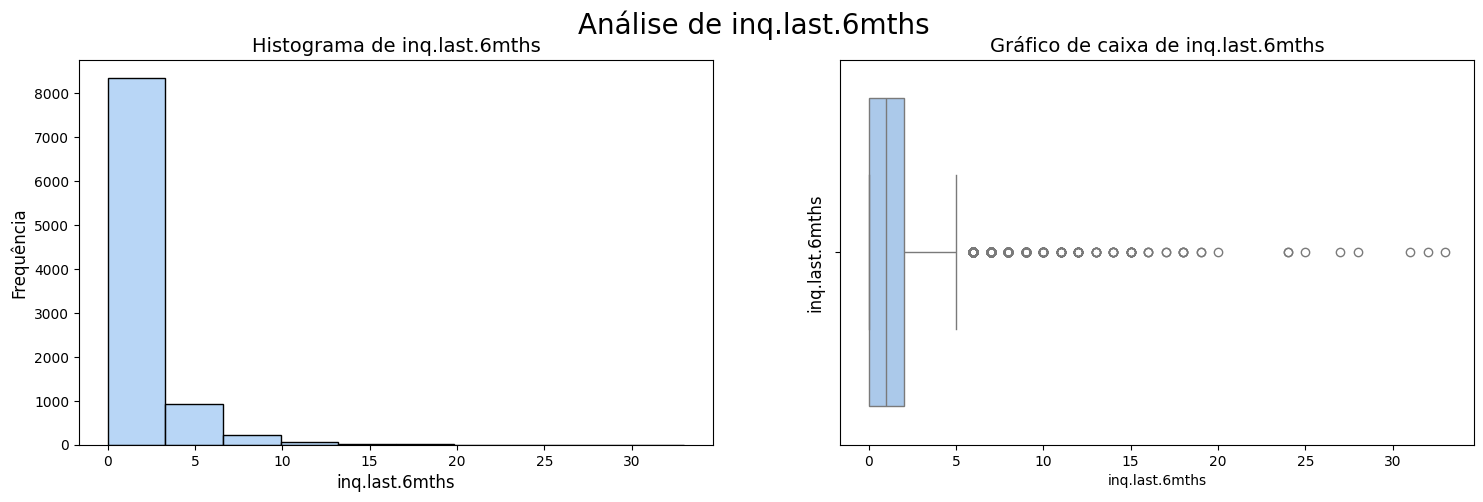

Skewness dos dados de delinq.2yrs é:  6.060843903702224


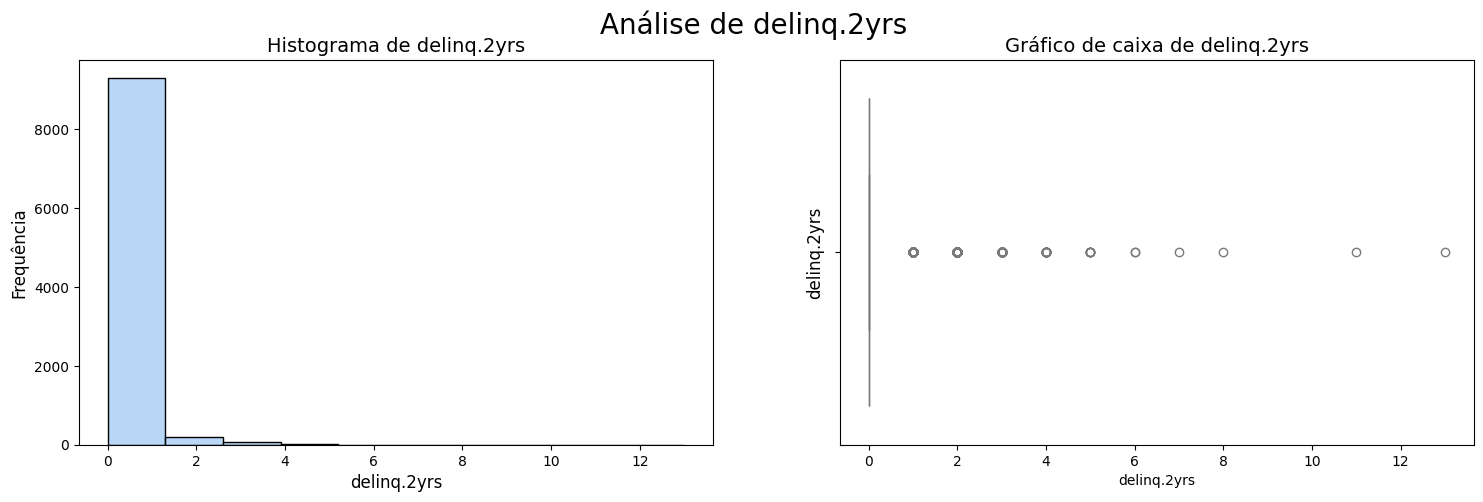

Skewness dos dados de pub.rec é:  5.125631579599643


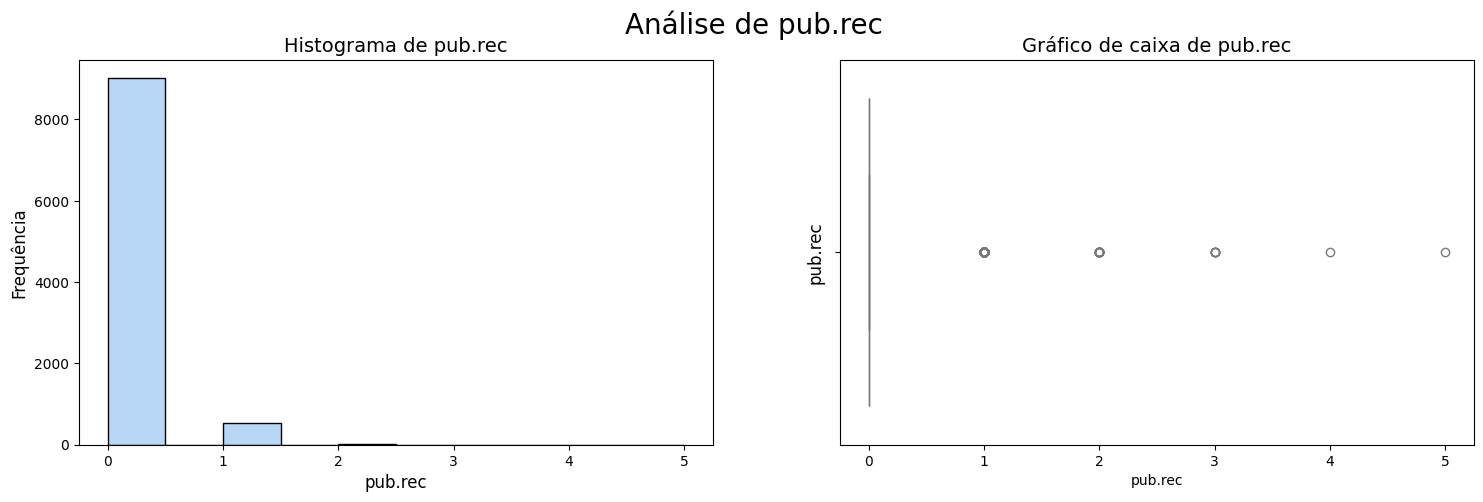

In [ ]:
#Gráficos numéricos
numerical_plot(df[num_cols])

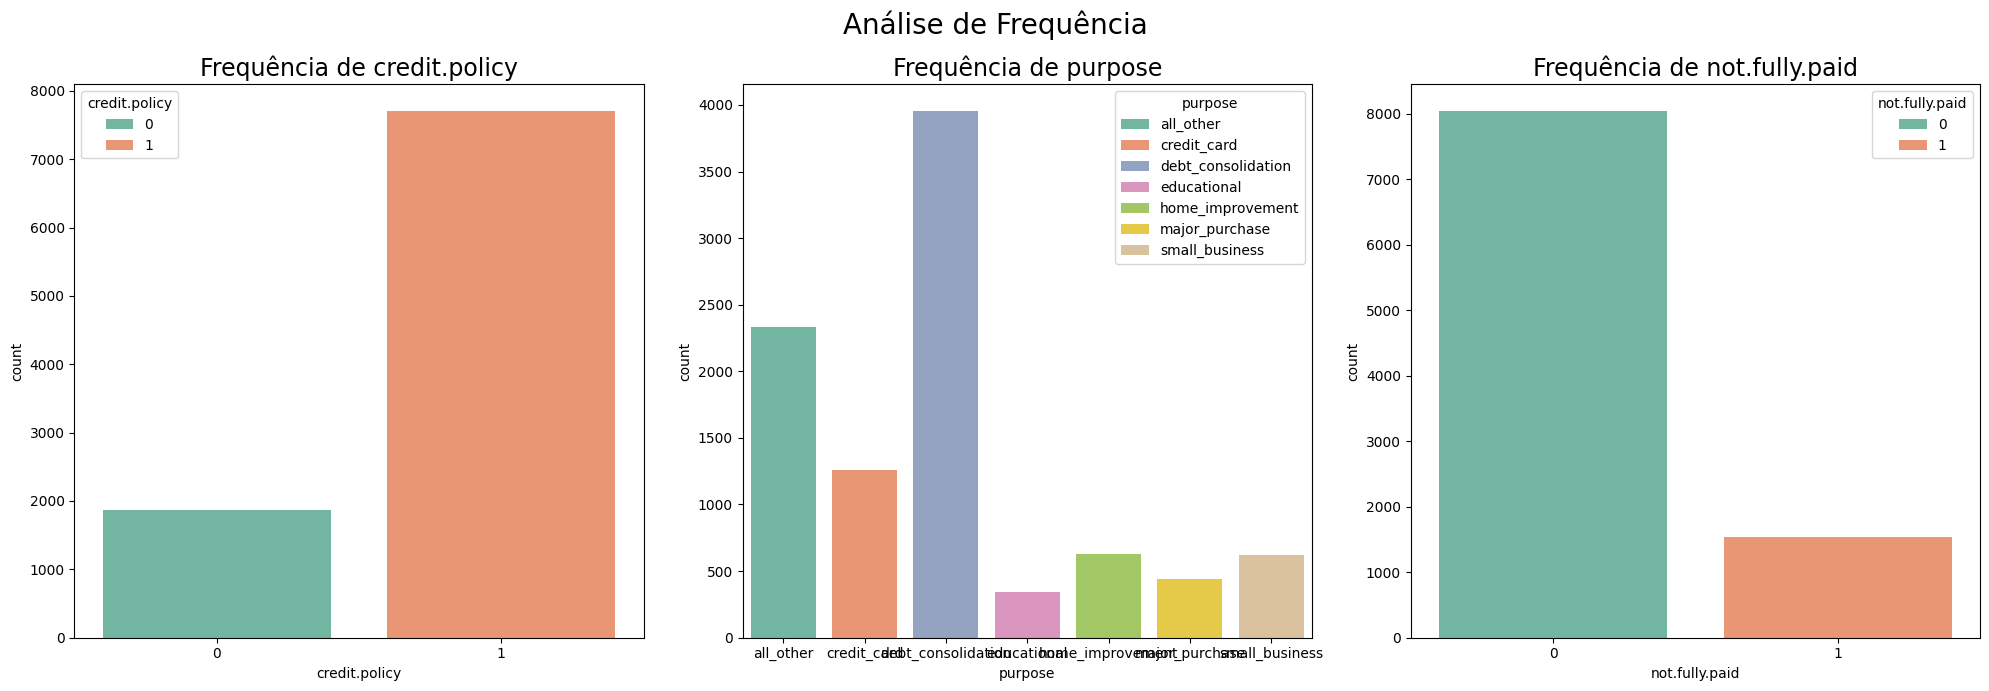

In [ ]:
#Gráficos categóricos
category_plot(df[cat_cols])

Normalização de variáveis

Skewness dos dados do logaritmo de days.with.cr.line é:  -0.8280492535138594 . Skewness sem o logaritmo é  1.1555672187692227


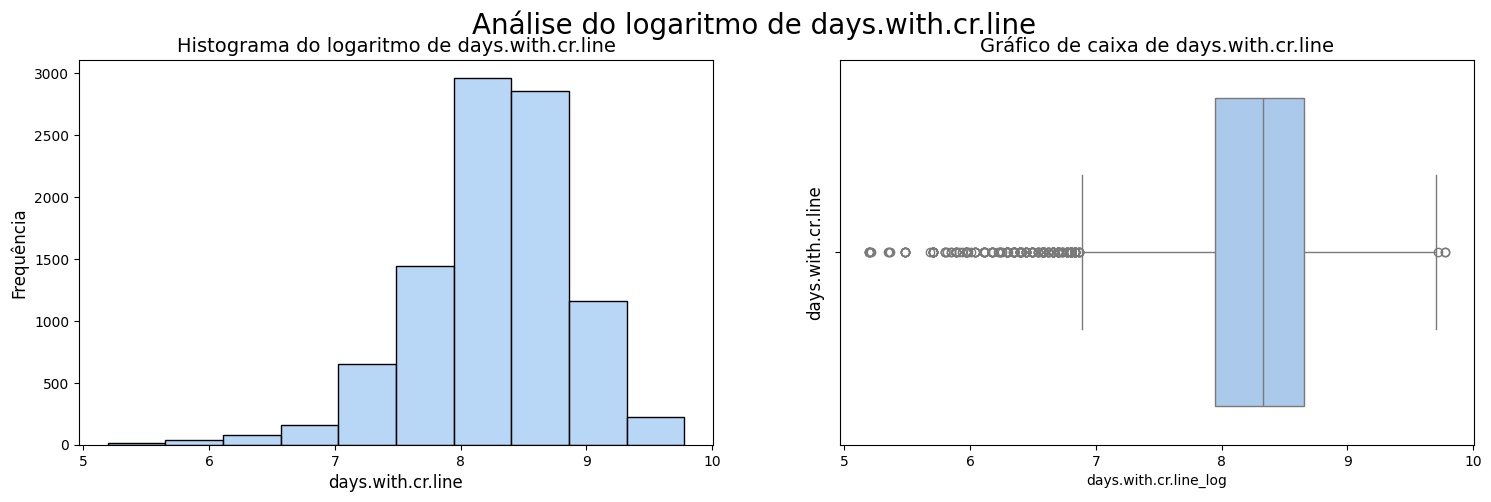

Skewness dos dados do logaritmo de revol.bal é:  -2.2136043885938292 . Skewness sem o logaritmo é  11.15931049753884


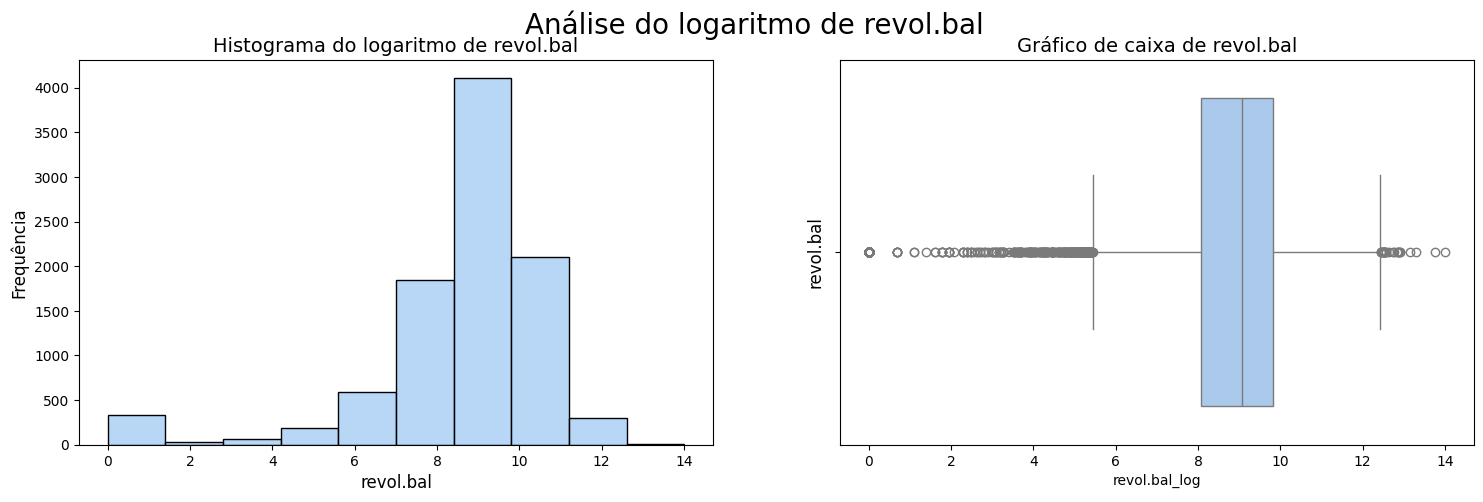

Skewness dos dados do logaritmo de inq.last.6mths é:  0.5584233599178882 . Skewness sem o logaritmo é  3.583589522053665


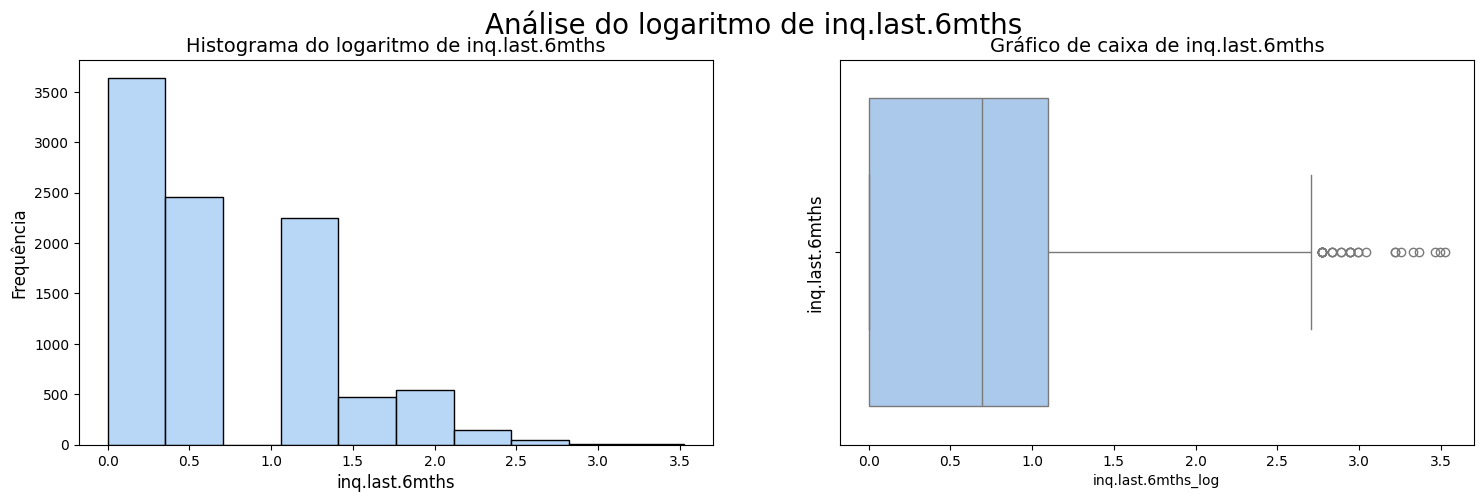

Skewness dos dados do logaritmo de delinq.2yrs é:  3.034242028458695 . Skewness sem o logaritmo é  6.060843903702224


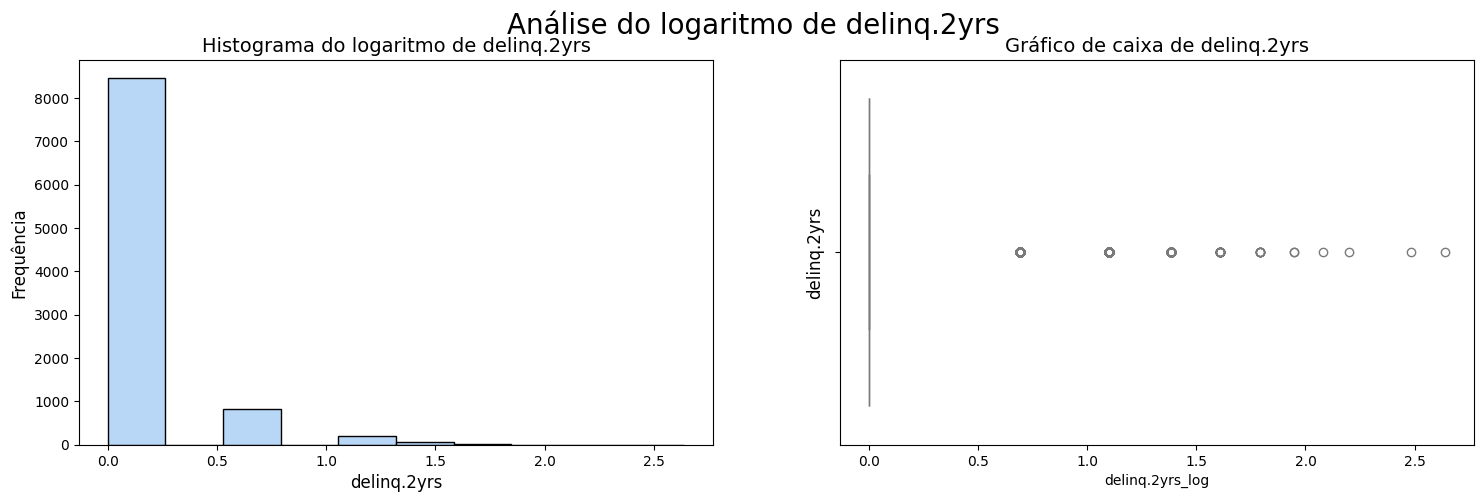

Skewness dos dados do logaritmo de pub.rec é:  4.027243217855413 . Skewness sem o logaritmo é  5.125631579599643


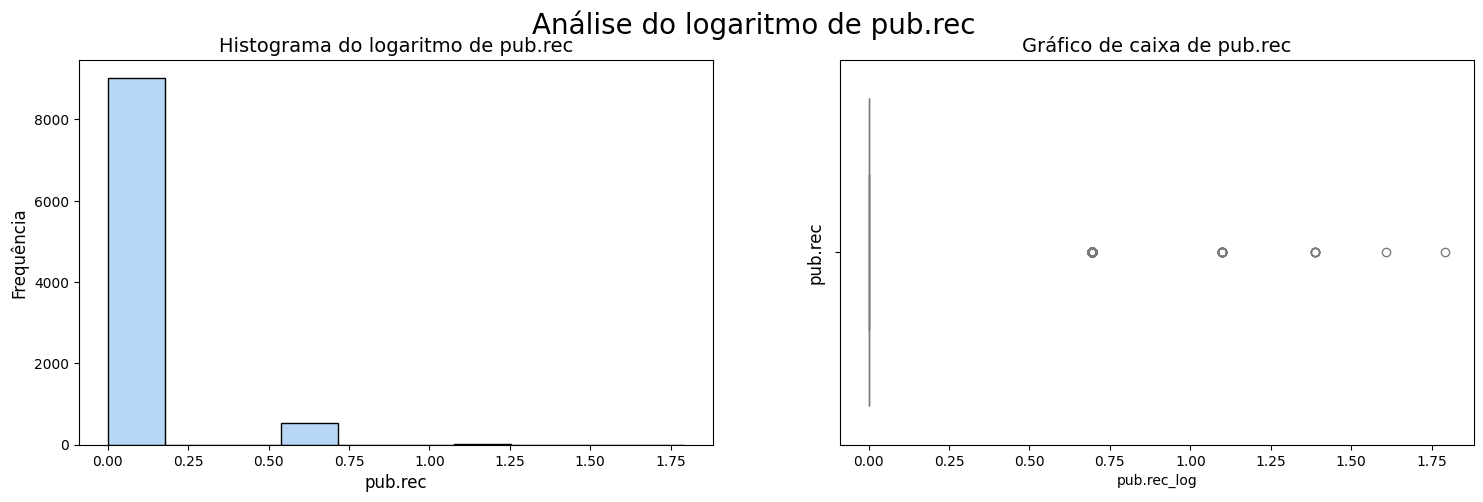

In [ ]:
#Normalizando a distribuição de variáveis com skewness maior do que 1, utilizando o logaritmo natural + 1
for col in num_cols:
  skew = stats.skew(df[col])
  if skew >= 1:
    df[col+'_log'] = np.log1p(df[col])
    skew_new = stats.skew(df[col+'_log'])
    if abs(skew_new) <= abs(skew):
      fig, axes = plt.subplots(1, 2, figsize=(18, 5))
      fig.suptitle(f'Análise do logaritmo de {col}', fontsize = 20)
      #Histograma
      sns.histplot(df[col+'_log'], ax=axes[0], bins = 10)
      axes[0].set_title(f'Histograma do logaritmo de {col}', fontsize=14)
      axes[0].set_xlabel(col, fontsize=12)
      axes[0].set_ylabel('Frequência', fontsize=12)
      #Gráfico de caixa
      sns.boxplot(x=df[col+'_log'], ax=axes[1])
      axes[1].set_title(f'Gráfico de caixa de {col}', fontsize=14)
      axes[1].set_ylabel(col, fontsize=12)
      print(f'Skewness dos dados do logaritmo de {col} é: ', skew_new, '. Skewness sem o logaritmo é ', skew)
      plt.show()
    else:
      df.drop(columns=[col+'_log'], inplace=True)

#Análise Bivariacional

<Axes: >

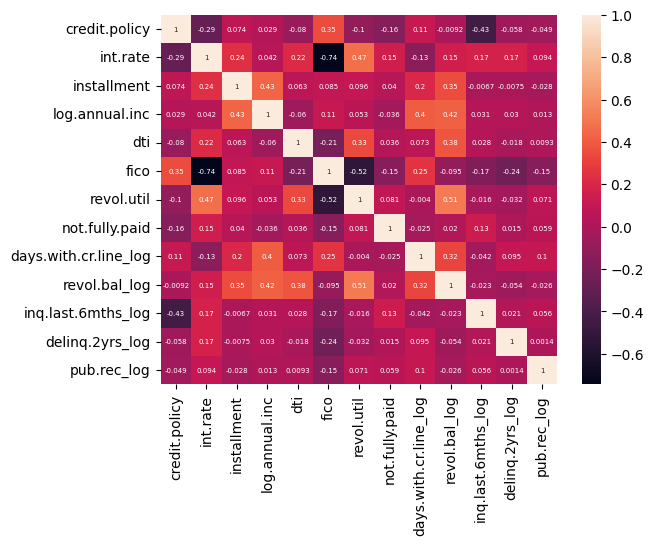

In [ ]:
#Mapa de correlação de variáveis
df_corr = df.drop(['purpose'], axis=1)
for col in df_corr.columns:
  if col+'_log' in df_corr.columns:
    df_corr.drop(columns=[col], inplace=True)
corr = df_corr.corr(method='spearman')
sns.heatmap(corr, annot=True, annot_kws={'size':5})

A taxa de não-pagamento para clientes que tem credit.policy igual a 0 é:  0.2778372591006424
A taxa de não-pagamento para clientes que tem credit.policy igual a 1 é:  0.13151750972762646


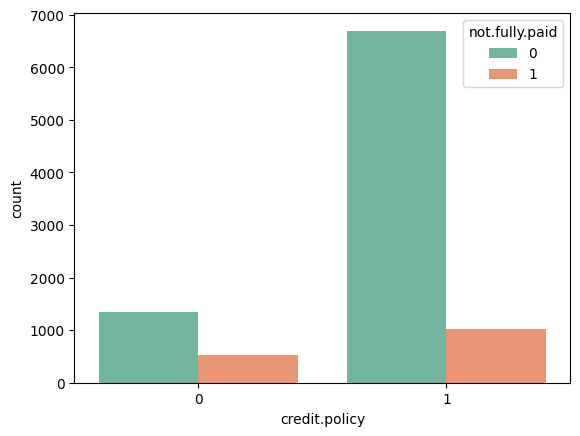

In [ ]:
#Taxa de clientes que se enquadram nas políticas de crédito que não pagam a dívida

sns.countplot(data = df, x = 'credit.policy', hue='not.fully.paid', palette='Set2')

for i in range(0, 2):
    df_cr = df[df['credit.policy']==i]
    not_paid_cr = df_cr['not.fully.paid'].value_counts()[1]
    total_clients = df_cr.shape[0]
    paying_rate = not_paid_cr/total_clients
    print(f'A taxa de não-pagamento para clientes que tem credit.policy igual a {i} é: ', paying_rate)

O valor mediano dos juros para clientes não-pagantes é:  0.1316
O valor mediano de juros para clientes pagantes é:  0.1218


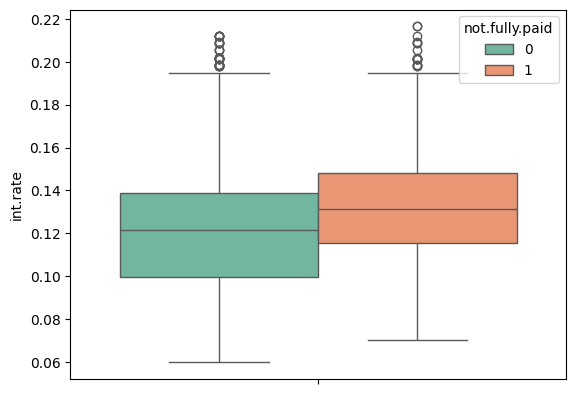

In [ ]:
#Efeito do valor dos juros na probabilidade de não-pagamento
sns.boxplot(data = df, y='int.rate', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['int.rate'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['int.rate'].median()
print('O valor mediano dos juros para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano de juros para clientes pagantes é: ', med_paid)

O valor mediano das parcelas para clientes não-pagantes é:  287.31
O valor mediano das parcelas para clientes pagantes é:  266.52


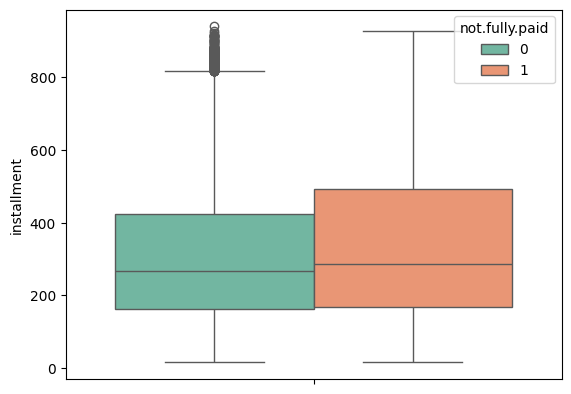

In [ ]:
#Efeito do valor da parcela na probabilidade de não-pagamento
sns.boxplot(data = df, y='installment', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['installment'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['installment'].median()
print('O valor mediano das parcelas para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano das parcelas para clientes pagantes é: ', med_paid)

O valor mediano do log do salário anual para clientes não-pagantes é:  10.87804719
O valor mediano do log do salário anual para clientes pagantes é:  10.9331784


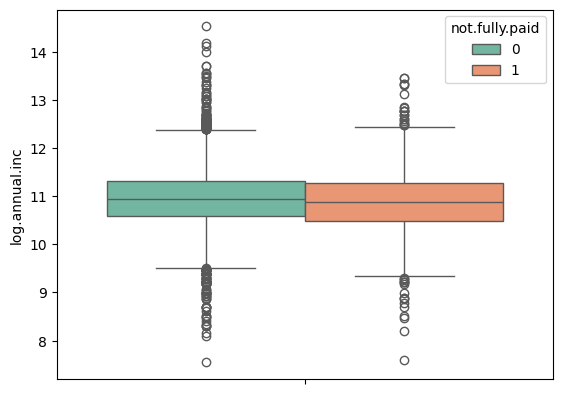

In [ ]:
#Efeito do logaritmo do salário anual na probabilidade de não-pagamento
sns.boxplot(data = df, y='log.annual.inc', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['log.annual.inc'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['log.annual.inc'].median()
print('O valor mediano do log do salário anual para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do log do salário anual para clientes pagantes é: ', med_paid)

O valor mediano da taxa débito/salário para clientes não-pagantes é:  13.34
O valor mediano da taxa débito/salário para clientes pagantes é:  12.53


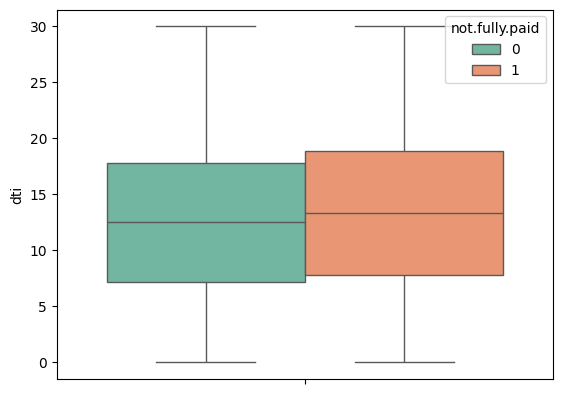

In [ ]:
#Efeito da taxa débito/salário na probabilidade de não-pagamento
sns.boxplot(data = df, y='dti', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['dti'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['dti'].median()
print('O valor mediano da taxa débito/salário para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano da taxa débito/salário para clientes pagantes é: ', med_paid)

O valor mediano do score de crédito para clientes não-pagantes é:  692.0
O valor mediano do score de crédito para clientes pagantes é:  707.0


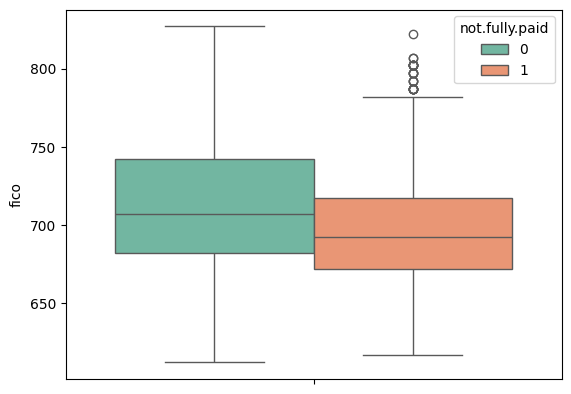

In [ ]:
#Efeito do score de crédito na probabilidade de não-pagamento
sns.boxplot(data = df, y='fico', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['fico'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['fico'].median()
print('O valor mediano do score de crédito para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do score de crédito para clientes pagantes é: ', med_paid)

O valor mediano da taxa crédito utilizado/crédito total disponível para clientes não-pagantes é:  53.9
O valor mediano da taxa crédito utilizado/crédito total disponível para clientes pagantes é:  44.8


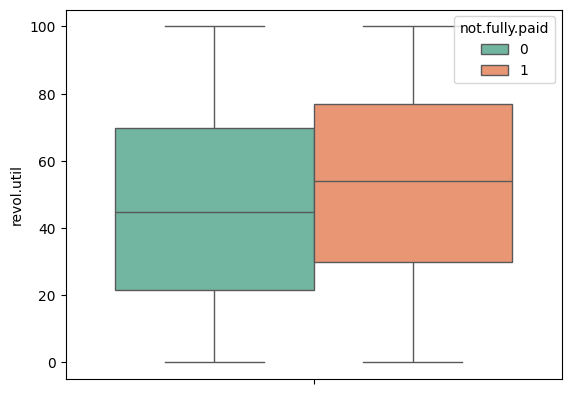

In [ ]:
#Efeito da taxa crédito utilizado/crédito total disponível na probabilidade de não-pagamento
sns.boxplot(data = df, y='revol.util', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['revol.util'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['revol.util'].median()
print('O valor mediano da taxa crédito utilizado/crédito total disponível para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano da taxa crédito utilizado/crédito total disponível para clientes pagantes é: ', med_paid)

O valor mediano da quantidade de dias com cartão de crédito para clientes não-pagantes é:  4050.0
O valor mediano da quantidade de dias com cartão de crédito para clientes pagantes é:  4140.041667


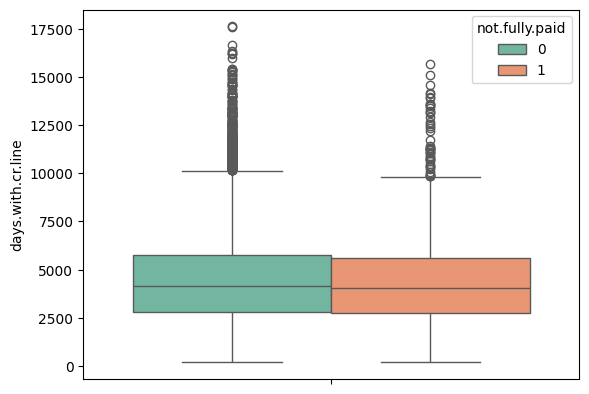

In [ ]:
#Efeito da quantidade de dias com cartão de crédito na probabilidade de não-pagamento
sns.boxplot(data = df, y='days.with.cr.line', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['days.with.cr.line'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['days.with.cr.line'].median()
print('O valor mediano da quantidade de dias com cartão de crédito para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano da quantidade de dias com cartão de crédito para clientes pagantes é: ', med_paid)

O valor mediano do crédito rotativo para clientes não-pagantes é:  8850.0
O valor mediano do crédito rotativo para clientes pagantes é:  8535.0


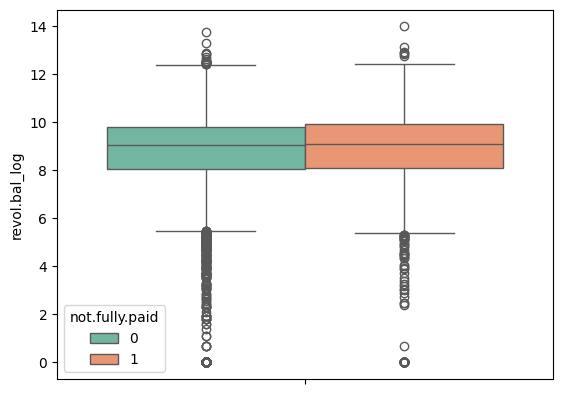

In [ ]:
#Efeito do crédito rotativo na probabilidade de não-pagamento
sns.boxplot(data = df, y='revol.bal_log', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['revol.bal'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['revol.bal'].median()
print('O valor mediano do crédito rotativo para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do crédito rotativo para clientes pagantes é: ', med_paid)

O valor mediano do número de cobranças nos últimos 6 meses para clientes não-pagantes é:  1.0
O valor mediano do número de cobranças nos últimos 6 meses para clientes pagantes é:  1.0


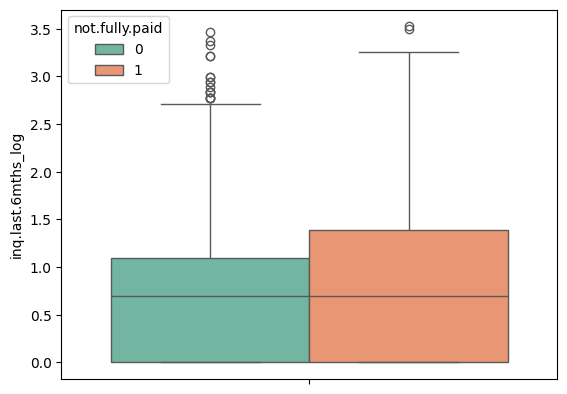

In [ ]:
#Efeito do número de cobranças nos últimos 6 meses na probabilidade de não-pagamento
sns.boxplot(data = df, y='inq.last.6mths_log', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['inq.last.6mths'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['inq.last.6mths'].median()
print('O valor mediano do número de cobranças nos últimos 6 meses para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do número de cobranças nos últimos 6 meses para clientes pagantes é: ', med_paid)

O valor mediano do número de vezes que o cliente atrasou mais do que 30 dias um pagamento nos últimos dois anos para clientes não-pagantes é:  0.0
O valor mediano do número de vezes que o cliente atrasou mais do que 30 dias um pagamento nos últimos dois anos para clientes pagantes é:  0.0


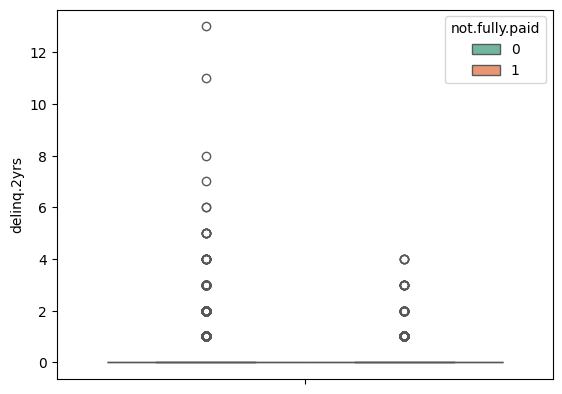

In [ ]:
#Efeito do número de vezes que o cliente atrasou mais do que 30 dias um pagamento nos últimos dois anos na probabilidade de não-pagamento
sns.boxplot(data = df, y='delinq.2yrs', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['delinq.2yrs'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['delinq.2yrs'].median()
print('O valor mediano do número de vezes que o cliente atrasou mais do que 30 dias um pagamento nos últimos dois anos para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do número de vezes que o cliente atrasou mais do que 30 dias um pagamento nos últimos dois anos para clientes pagantes é: ', med_paid)

O valor mediano do número de registros públicos negativos relacionados a finanças do cliente para clientes não-pagantes é:  0.0
O valor mediano do número de registros públicos negativos relacionados a finanças do cliente para clientes pagantes é:  0.0


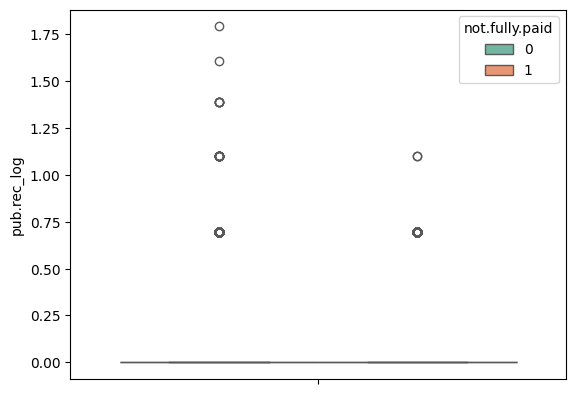

In [ ]:
#Efeito do número de registros públicos negativos relacionados a finanças do cliente na probabilidade de não-pagamento
sns.boxplot(data = df, y='pub.rec_log', hue ='not.fully.paid', palette='Set2')

not_paid = df[df['not.fully.paid'] == 1]
med_not_paid = not_paid['pub.rec'].median()
paid = df[df['not.fully.paid'] == 0]
med_paid = paid['pub.rec'].median()
print('O valor mediano do número de registros públicos negativos relacionados a finanças do cliente para clientes não-pagantes é: ', med_not_paid)
print('O valor mediano do número de registros públicos negativos relacionados a finanças do cliente para clientes pagantes é: ', med_paid)

In [ ]:
#Criando um dataframe para analisar a mediana de cada coluna por purpose
purposes = df['purpose'].unique()
df_sem_purp = df.drop('purpose', axis = 1)
list_purp = []
list_cols = []
list_total_med =[]
list_purp_med = []
for purpose in purposes:
  for col in df_sem_purp.columns:
    list_purp.append(purpose)
    list_cols.append(col)
    if df_sem_purp[col].dtype != 'category':
      total_med = df_sem_purp[col].median()
      list_total_med.append(total_med)
      med_purp = df[df['purpose'] == purpose][col].median()
      list_purp_med.append(med_purp)
    else:
      total_med = df_sem_purp[col].value_counts()[1]/df_sem_purp.shape[0]
      list_total_med.append(total_med)
      purp_med = df[df['purpose'] == purpose][col].value_counts()[1]/df[df['purpose'] == purpose].shape[0]
      list_purp_med.append(purp_med)
data_purpose = {
    "purpose": list_purp,
    "col": list_cols,
    "total_median": list_total_med,
    "purpose_median": list_purp_med
}
df_purpose = pd.DataFrame(data_purpose)

In [ ]:
#Selecionando as colunas em que a mediana da coluna por purpose tem uma diferença percentual maior do que 25% da mediana da coluna de todo o dataset
df_purpose[(np.abs((df_purpose['total_median']-df_purpose['purpose_median']))/df_purpose['total_median'])* 100 > 25]

,purpose,col,total_median,purpose_median
7,debt_consolidation,revol.bal,8596.000000,10868.000000
25,credit_card,revol.bal,8596.000000,13645.000000
30,credit_card,not.fully.paid,0.160054,0.115689
38,all_other,installment,268.950000,190.630000
43,all_other,revol.bal,8596.000000,4689.000000
62,home_improvement,revol.util,46.300000,30.000000
74,small_business,installment,268.950000,394.360000
84,small_business,not.fully.paid,0.160054,0.277868
92,major_purchase,installment,268.950000,198.780000
97,major_purchase,revol.bal,8596.000000,3309.000000


#Processamento de Dados

In [ ]:
#Tirando variáveis que transformamos anteriormente
for col in df.columns:
  if col+'_log' in df.columns:
    df.drop(columns=[col], inplace=True)
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,revol.util,not.fully.paid,days.with.cr.line_log,revol.bal_log,inq.last.6mths_log,delinq.2yrs_log,pub.rec_log
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,52.1,0,8.637809,10.270039,0.000000,0.000000,0.0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,76.7,0,7.923348,10.422995,0.000000,0.000000,0.0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,25.6,0,8.457655,8.163941,0.693147,0.000000,0.0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,73.2,0,7.901362,10.424303,0.693147,0.000000,0.0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,39.5,0,8.310661,8.464003,0.000000,0.693147,0.0


In [ ]:
#Fazendo one-hot encoding de purpose
df = pd.get_dummies(df, columns=['purpose'], dtype='int')

In [ ]:
#Separando em grupos de treino e teste, e fazendo resampling para balancear o dataset
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop(['not.fully.paid'], axis=1)
y = df['not.fully.paid']

X_arr = np.array(X)
y_arr = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X_arr, y_arr, test_size = 0.3, random_state = 778, stratify=y)

smote = SMOTE(random_state=2)

X_train, y_train = smote.fit_resample(X_train, y_train)
X_test, y_test = smote.fit_resample(X_test, y_test)

In [ ]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
scaler.transform(X_test)

array([[ 0.62171423,  1.31519455, -0.71351835, ..., -0.2935463 ,
        -0.21844549, -0.32623163],
       [ 0.62171423, -1.24195592, -1.08543648, ..., -0.2935463 ,
         5.093007  , -0.32623163],
       [ 0.62171423, -2.14379067, -0.23477168, ..., -0.2935463 ,
        -0.21844549, -0.32623163],
       ...,
       [ 0.62171423,  0.4885917 ,  1.01287635, ..., -0.2935463 ,
        -0.21844549, -0.32623163],
       [-1.0790403 ,  1.25437452,  0.92065067, ..., -0.2935463 ,
        -0.21844549, -0.32623163],
       [ 0.62171423,  0.69544412,  0.87133592, ..., -0.2935463 ,
        -0.21844549,  1.20197521]])

#Treino de Modelos

In [ ]:
#Modelo de Regressão Logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(solver = 'liblinear')
log_reg.fit(X_train, y_train)
preds = log_reg.predict(X_test)
roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
print('Regressão Logística:')
print('Acurácia: ', accuracy_score(y_test, preds))
print('Outras métricas: ')
print(classification_report(y_test, preds))
print('Valor ROC-AUC: ', roc_auc)
print('Matriz de confusão:')
print(confusion_matrix(y_test, preds))

Regressão Logística:
Acurácia:  0.6375310687655343
Outras métricas: 
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      2414
           1       0.65      0.60      0.62      2414

    accuracy                           0.64      4828
   macro avg       0.64      0.64      0.64      4828
weighted avg       0.64      0.64      0.64      4828

Valor ROC-AUC:  0.6902952879811153
Matriz de confusão:
[[1629  785]
 [ 965 1449]]


In [ ]:
#Modelo de Árvore de Decisão

from sklearn.tree import DecisionTreeClassifier

param_grid=[{'min_samples_split':[0.001, 0.005, 0.01, 0.1, 0.3]}]
tree = DecisionTreeClassifier(random_state=778)
grid2 = GridSearchCV(tree, param_grid, cv=7, scoring=['roc_auc'], refit='roc_auc')
grid2.fit(X_train, y_train)
preds = grid2.predict(X_test)
roc_auc = roc_auc_score(y_test, grid2.predict_proba(X_test)[:, 1])
print('Árvore de Decisão:')
print('Acurácia: ', accuracy_score(y_test, preds))
print('Outras métricas: ')
print(classification_report(y_test, preds))
print('Valor ROC-AUC: ', roc_auc)
print('Melhores parâmetros: {}'.format(grid2.best_params_))
print('Matriz de confusão:')
print(confusion_matrix(y_test, preds))

Árvore de Decisão:
Acurácia:  0.8260149130074566
Outras métricas: 
              precision    recall  f1-score   support

           0       0.76      0.94      0.84      2414
           1       0.92      0.71      0.80      2414

    accuracy                           0.83      4828
   macro avg       0.84      0.83      0.82      4828
weighted avg       0.84      0.83      0.82      4828

Valor ROC-AUC:  0.8729226570495638
Melhores parâmetros: {'min_samples_split': 0.01}
Matriz de confusão:
[[2273  141]
 [ 699 1715]]


In [ ]:
#Modelo de Floresta de Decisão
from sklearn.ensemble import RandomForestClassifier

param_grid=[{'n_estimators':[50, 100, 200,300],
            'min_samples_split':[0.05, 0.1, 0.2, 0.3]}]
forest = RandomForestClassifier(random_state=778)
grid = GridSearchCV(forest, param_grid, cv=7, scoring=['roc_auc'], refit='roc_auc')
grid.fit(X_train, y_train)
preds = grid.predict(X_test)
roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print('Floresta de Decisão:')
print('Acurácia: ', accuracy_score(y_test, preds))
print('Outras métricas: ')
print(classification_report(y_test, preds))
print('Valor ROC-AUC: ', roc_auc)
print('Melhores parâmetros: {}'.format(grid.best_params_))
print('Matriz de confusão:')
print(confusion_matrix(y_test, preds))

Floresta de Decisão:
Acurácia:  0.8316072908036454
Outras métricas: 
              precision    recall  f1-score   support

           0       0.79      0.91      0.84      2414
           1       0.89      0.76      0.82      2414

    accuracy                           0.83      4828
   macro avg       0.84      0.83      0.83      4828
weighted avg       0.84      0.83      0.83      4828

Valor ROC-AUC:  0.8993204683532747
Melhores parâmetros: {'min_samples_split': 0.05, 'n_estimators': 100}
Matriz de confusão:
[[2192  222]
 [ 591 1823]]


In [ ]:
#Modelo Ada Boost
from sklearn.ensemble import AdaBoostClassifier

param_grid=[{'n_estimators':[25, 50, 100, 150],
            'learning_rate':[0.05,0.1, 0.5, 1, 1.2]}]
ada = AdaBoostClassifier(random_state=778)
grid = GridSearchCV(ada, param_grid, cv=7, scoring=['roc_auc'], refit='roc_auc')
grid.fit(X_train, y_train)
preds = grid.predict(X_test)
roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print('ADA Boost:')
print('Acurácia: ', accuracy_score(y_test, preds))
print('Outras métricas: ')
print(classification_report(y_test, preds))
print('Valor ROC-AUC: ', roc_auc)
print('Melhores parâmetros: {}'.format(grid.best_params_))
print('Matriz de confusão:')
print(confusion_matrix(y_test, preds))

ADA Boost:
Acurácia:  0.8670256835128417
Outras métricas: 
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      2414
           1       0.97      0.76      0.85      2414

    accuracy                           0.87      4828
   macro avg       0.89      0.87      0.87      4828
weighted avg       0.89      0.87      0.87      4828

Valor ROC-AUC:  0.9198541681395944
Melhores parâmetros: {'learning_rate': 1.2, 'n_estimators': 150}
Matriz de confusão:
[[2356   58]
 [ 584 1830]]


In [ ]:
#Modelo Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

param_grid=[{'n_estimators':[25, 50, 100, 200],
            'learning_rate':[0.1, 0.5, 1]}]
gbc = GradientBoostingClassifier(random_state=778)
grid = GridSearchCV(gbc, param_grid, cv=7, scoring=['roc_auc'], refit='roc_auc')
grid.fit(X_train, y_train)
preds = grid.predict(X_test)
roc_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print('Gradient Boosting:')
print('Acurácia: ', accuracy_score(y_test, preds))
print('Outras métricas: ')
print(classification_report(y_test, preds))
print('Valor ROC-AUC: ', roc_auc)
print('Melhores parâmetros: {}'.format(grid.best_params_))
print('Matriz de confusão:')
print(confusion_matrix(y_test, preds))

Gradient Boosting:
Acurácia:  0.8759320629660314
Outras métricas: 
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      2414
           1       0.98      0.77      0.86      2414

    accuracy                           0.88      4828
   macro avg       0.89      0.88      0.87      4828
weighted avg       0.89      0.88      0.87      4828

Valor ROC-AUC:  0.9241671580239269
Melhores parâmetros: {'learning_rate': 0.1, 'n_estimators': 200}
Matriz de confusão:
[[2374   40]
 [ 559 1855]]
